# AIM is to save document into database

#### installed : 
```bash
pip install pandas
```

In [101]:
from dotenv import load_dotenv
load_dotenv()
import psycopg2
import os
import sys
import pandas as pd
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import ollama

In [102]:
sys.path.append(r'D:\Rushal\VS_code\Python\ProjectIII\backend\ai\documents\created_doc')
os.chdir(r'D:\Rushal\VS_code\Python\ProjectIII\backend')


In [103]:
base_path = r"ai/documents/question_answers/"
# base_path = r""

In [104]:
all_files = os.listdir(base_path)
all_files
# backend\ai\documents

['hardquestions.xlsx', 'mediumquestions.xlsx', 'simple_questions.xlsx']

In [105]:
# ============================================================
# 1. Define Profile Prototypes (6 levels)
# ============================================================
experience_profiles = {
    "none": """
    Entry-level interview question suitable for a candidate with no
    professional work experience. Focuses on basic knowledge, fundamental
    concepts, education, personal projects, learning ability, motivation,
    communication, and theoretical understanding. Does not require
    previous job experience.
    """,
    
    "intern": """
    Internship-level interview question suitable for a student or beginner
    with limited practical industry experience. Focuses on learning,
    academic projects, basic technical skills, willingness to learn,
    teamwork, guidance, and applying knowledge under supervision.
    """,

    "junior": """
    Junior-level interview question suitable for a professional with
    approximately one to two years of experience. Focuses on practical
    skills, basic independent work, implementing solutions, debugging,
    collaboration, learning from senior colleagues, and handling
    moderately challenging tasks.
    """,

    "mid_level": """
    Mid-level interview question suitable for a professional with
    approximately three to five years of experience. Requires independent
    problem solving, ownership of features or projects, solid practical
    expertise, handling complex tasks, making technical decisions,
    collaborating across teams, and improving existing systems.
    """,

    "senior": """
    Senior-level interview question requiring strong technical expertise,
    independent decision making, system design, leadership, mentoring,
    complex problem solving, architecture, ownership, strategic thinking,
    and significant professional experience.
    """,

    "any": """
    General interview question that can be asked to candidates regardless
    of their professional experience level. Focuses on universal skills,
    personality, motivation, communication, work style, adaptability,
    career goals, or general knowledge rather than a specific amount of
    professional experience.
    """
}

In [106]:
dfs=[]
for file in all_files:
    filepath = base_path + file
    dfs.append(pd.read_excel(filepath))
    print(f"file loaded {filepath}")

file loaded ai/documents/question_answers/hardquestions.xlsx
file loaded ai/documents/question_answers/mediumquestions.xlsx
file loaded ai/documents/question_answers/simple_questions.xlsx


In [107]:
from ai.utils.embeddings import embed_text_local

In [113]:
# dfs[0].drop('roles',axis=1,inplace=True)
print(dfs[0].columns.tolist())
print(dfs[1].columns.tolist())
# dfs[2] = dfs[2].rename(columns={'ideal_answer':'answer'})
print(dfs[2].columns.tolist())

['question', 'role', 'answer', 'keywords', 'difficulty']
['role', 'question', 'keywords', 'answer', 'difficulty']
['question', 'role', 'answer', 'keywords', 'difficulty']


In [111]:
x=2
dfs[0]['difficulty']='easy'
dfs[1]['difficulty']='medium'
dfs[2]['difficulty']='hard'


In [112]:
merged_df = pd.concat([dfs[0], dfs[1], dfs[2]], ignore_index=True)

In [114]:
merged_df.difficulty.unique()

<StringArray>
['easy', 'medium', 'hard']
Length: 3, dtype: str

In [115]:
em = embed_text_local("thik xau")
em[:3]

[-0.49727994203567505, 0.2624587416648865, -3.3480136394500732]

In [130]:
fake_df = merged_df

# Lets Do Some Dhaaasu

In [131]:
# ============================================================
# 2. Embed All Profiles
# ============================================================
def get_embedding(text):
    return ollama.embeddings(model='nomic-embed-text', prompt=text)['embedding']

profile_embeddings = {
    level: get_embedding(text) for level, text in experience_profiles.items()
}
profile_matrix = np.array(list(profile_embeddings.values()))

In [132]:
# ============================================================
# 3. Score Each Row Against All Profiles
# ============================================================
def assign_experience(row_text, profile_matrix, profile_names):
    """Assign experience level based on max cosine similarity."""
    row_embed = get_embedding(row_text)
    similarities = cosine_similarity([row_embed], profile_matrix)[0]  # Shape: (6,)
    
    # Get best match
    best_idx = np.argmax(similarities)
    assigned_level = profile_names[best_idx]
    confidence_score = similarities[best_idx]
    
    return {
        "assigned_level": assigned_level,
        "confidence_score": confidence_score,
        "all_scores": dict(zip(profile_names, similarities))
    }

In [133]:
fake_df

,question,role,answer,keywords,difficulty
0,You've been tasked with implementing a new net...,Network Engineer,"That's a real situation, and I'd approach it m...","been, tasked, implementing, new, network, infr...",easy
1,Suppose we're planning to develop a new AI-pow...,Engineering Manager,"That's a real situation, and I'd approach it m...","Suppose, planning, develop, new, AI-powered, a...",easy
2,You've been tasked to perform a penetration te...,Penetration Tester / Ethical Hacker,I'd treat this as a case of balancing competin...,"been, tasked, perform, penetration, test, our,...",easy
3,Scenario: The DevOps team has been experiencin...,Scrum Master / Agile Coach,Good question — this is the kind of trade-off ...,"Scenario, DevOps, team, been, experiencing, in...",easy
4,In our current project to develop an autonomou...,Solutions Architect,Good question — this is the kind of trade-off ...,"our, current, project, develop, autonomous, dr...",easy
...,...,...,...,...,...
20909,What motivates you to come to work every day?,Product Manager,I'm motivated by challenges and the opportunit...,"['drive', 'passion']",hard
20910,Describe a time you handled a difficult situat...,QA Analyst,"When faced with conflict, I approach it calmly...","['resolve', 'problem']",hard
20911,Where do you see yourself in 5 years?,HR Specialist,My long-term goal is to grow into a senior rol...,"['next step', 'dream']",hard
20912,Tell me about a time you had to learn somethin...,Product Manager,I'm always eager to learn and embrace change a...,"['new', 'change']",hard


In [134]:
# ============================================================
# 4. Process Your Dataset
# ============================================================
fake_df
profile_names = list(experience_profiles.keys())

results = []
for _, row in fake_df.iterrows():
    combined_text = f"Question: {row['question']}\nAnswer: {row['answer']}"
    result = assign_experience(combined_text, profile_matrix, profile_names)
    results.append(result)

# Add to dataframe
fake_df['assigned_experience'] = [r['assigned_level'] for r in results]
fake_df['confidence'] = [r['confidence_score'] for r in results]

In [120]:
# ============================================================
# 5. Visualization: Similarity Heatmap for a Sample Row
# ============================================================
def plot_similarity_for_row(row_index):
    """Show how this row scored against all 6 profiles."""
    sample = results[row_index]
    levels = profile_names
    scores = [sample['all_scores'][level] for level in levels]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(levels, scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
    plt.axhline(y=sample['confidence_score'], color='red', linestyle='--', label=f"Winner: {sample['assigned_level']} ({sample['confidence_score']:.3f})")
    plt.xlabel('Experience Profile')
    plt.ylabel('Cosine Similarity')
    plt.title(f'Similarity Scores for Row {row_index+1}')
    plt.legend()
    plt.ylim(0, 1)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig(f'similarity_row_{row_index+1}.png')
    plt.show()

# Plot first row as example
plot_similarity_for_row(0)

IndexError: list index out of range

In [144]:
# ============================================================
# 6. Overall Distribution Visualization
# ============================================================
def plot_assignment_distribution():
    """Show how many rows assigned to each experience level."""
    ax = fake_df['assigned_experience'].value_counts().plot(kind='bar', color='skyblue')
    ax.set_xlabel('Experience Level')
    ax.set_ylabel('Number of Rows')
    ax.set_title('Distribution of Assigned Experience Levels')
    
    for i, v in enumerate(fake_df['assigned_experience'].value_counts().values):
        plt.text(i, v + 5, str(v), ha='center')
    
    plt.tight_layout()
    plt.savefig('assignment_distribution.png')
    plt.show()

# ============================================================
# 7. Export Results
# ============================================================
fake_df.to_csv('all.csv', index=False)
print("✅ Results exported to 'med_qno_with_experience.csv'")

✅ Results exported to 'med_qno_with_experience.csv'


In [136]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
from pprint import pprint

In [137]:

for i,row in fake_df.iterrows():
    if row.assigned_experience.lower() == "senior":
        print(row.question,row.answer)
        break
    print("count",i)

count 0
Suppose we're planning to develop a new AI-powered anomaly detection system for our drone fleets, aiming to increase flight safety and efficiency. As the Engineering Manager, you've been tasked with selecting an appropriate machine learning framework and associated tooling to handle real-time data processing at scale. Given the complexities of our drones' telemetry data and regulatory requirements like privacy and latency, could you discuss your rationale for choosing between TensorFlow or PyTorch, and explain which supporting tools (e.g., Dask or Horovod) and architectural patterns (e.g., event-driven or microservices) would best suit our needs? That's a real situation, and I'd approach it methodically rather than reacting immediately. I'd evaluate the options against our concrete constraints rather than hype, running a small proof of concept before committing, paying close attention to AI, anomaly detection, TensorFlow, PyTorch since those are the constraints that actually dr

In [138]:
fake_df

,question,role,answer,keywords,difficulty,assigned_experience,confidence
0,"You've been tasked with implementing a new network infrastructure for our IoT device farm, which currently consists of 500 devices. A key requirement is to ensure minimal latency while complying with HACCP regulations. However, your team discovered an issue during the design phase that could potentially double the network setup time due to a complex topology involving VXLAN and QoS settings. The deadline for this project is in two weeks, and another important project involving our online ordering system is also approaching its deadline. One of your colleagues suggests postponing the IoT device farm project while you prioritize the online ordering system. How would you approach this situation to ensure both projects are completed on time without compromising network performance or HACCP compliance?",Network Engineer,"That's a real situation, and I'd approach it methodically rather than reacting immediately. I'd start by getting clarity on priorities directly from stakeholders rather than assuming, then communicate trade-offs transparently to everyone affected, paying close attention to IoT device farm, minimal latency, HACCP regulations, VXLAN since those are the constraints that actually drive the right answer here. Concretely, I'd lay out the options, flag the risks tied to IoT device farm, and agree with stakeholders on which trade-off we're willing to accept before committing to a plan. Given the competing pressures here, I'd rather over-communicate the trade-off up front than let it become a surprise later. I'd also make sure to keep my manager and the affected teams in the loop throughout, since clear communication is what keeps trust intact even when timelines are tight.","been, tasked, implementing, new, network, infrastructure, our, IoT",easy,mid_level,0.572292
1,"Suppose we're planning to develop a new AI-powered anomaly detection system for our drone fleets, aiming to increase flight safety and efficiency. As the Engineering Manager, you've been tasked with selecting an appropriate machine learning framework and associated tooling to handle real-time data processing at scale. Given the complexities of our drones' telemetry data and regulatory requirements like privacy and latency, could you discuss your rationale for choosing between TensorFlow or PyTorch, and explain which supporting tools (e.g., Dask or Horovod) and architectural patterns (e.g., event-driven or microservices) would best suit our needs?",Engineering Manager,"That's a real situation, and I'd approach it methodically rather than reacting immediately. I'd evaluate the options against our concrete constraints rather than hype, running a small proof of concept before committing, paying close attention to AI, anomaly detection, TensorFlow, PyTorch since those are the constraints that actually drive the right answer here. Concretely, I'd lay out the options, flag the risks tied to AI, and agree with stakeholders on which trade-off we're willing to accept before committing to a plan. This is the kind of situation where sticking to the fundamentals and being methodical pays off. I'd frame the recommendation in terms of business impact and risk so leadership can make an informed call quickly.","Suppose, planning, develop, new, AI-powered, anomaly, detection, system",easy,senior,0.587011
2,"You've been tasked to perform a penetration test on our web application, which is built using Django and AngularJS. The application handles sensitive financial data. Upon initial scan, you discover that we haven't properly implemented CSRF protection for certain endpoints. Explain your approach to exploit this vulnerability, mitigate the risk, and suggest long-term preventive measures.",Penetration Tester / Ethical Hacker,"I'd treat this as a case of balancing competing constraints rather than picking one side outright. I'd weigh the tools against our team's existing skill set, the maintenance burde

In [145]:
assigned_df = pd.read_csv("all.csv")

In [146]:
assigned_df[assigned_df['assigned_experience'] == 'none'].shape[0]

0

In [147]:
assigned_df['assigned_experience'].value_counts()

assigned_experience
mid_level    17141
senior        3552
any            198
intern          22
junior           1
Name: count, dtype: int64

assigned_experience
mid_level    17141
senior        3552
any            198
intern          22
junior           1
Name: count, dtype: int64


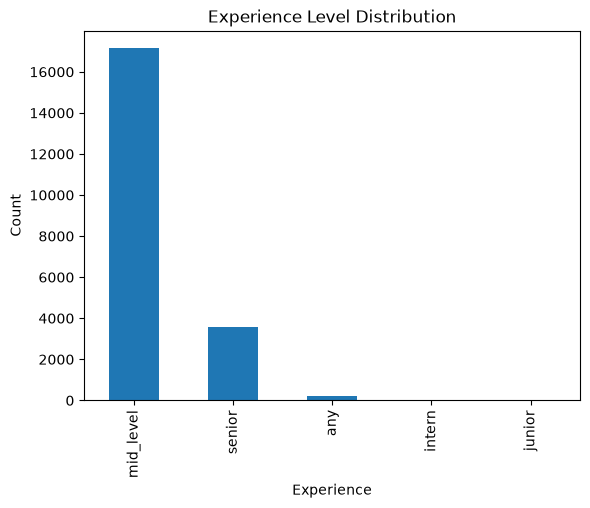

In [148]:
# Visualize all experience levels
print(assigned_df['assigned_experience'].value_counts())
assigned_df['assigned_experience'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.xlabel('Experience')
plt.ylabel('Count')
plt.show()

In [153]:
assigned_df.shape

(20914, 7)

In [ ]:
unique_roles = df['role'].unique()
print(unique_roles)

with open('roles.json','w') as f:
    json.dumps(unique_roles)

<StringArray>
[                            'Network Engineer',
                          'Engineering Manager',
          'Penetration Tester / Ethical Hacker',
                   'Scrum Master / Agile Coach',
                          'Solutions Architect',
                            'Platform Engineer',
                 'Database Administrator (DBA)',
        'Blockchain / Smart Contract Developer',
                               'MLOps Engineer',
                     'Computer Vision Engineer',
                               'Game Developer',
                               'Data Scientist',
                   'Sales / Solutions Engineer',
                    'Technical Product Manager',
            'Security Operations (SOC) Analyst',
                               'UX/UI Designer',
           'Business Intelligence (BI) Analyst',
                                'Data Engineer',
                                 'NLP Engineer',
                     'Test Automation Engineer',
      

In [ ]:
unique_roles

<StringArray>
[                            'Network Engineer',
                          'Engineering Manager',
          'Penetration Tester / Ethical Hacker',
                   'Scrum Master / Agile Coach',
                          'Solutions Architect',
                            'Platform Engineer',
                 'Database Administrator (DBA)',
        'Blockchain / Smart Contract Developer',
                               'MLOps Engineer',
                     'Computer Vision Engineer',
                               'Game Developer',
                               'Data Scientist',
                   'Sales / Solutions Engineer',
                    'Technical Product Manager',
            'Security Operations (SOC) Analyst',
                               'UX/UI Designer',
           'Business Intelligence (BI) Analyst',
                                'Data Engineer',
                                 'NLP Engineer',
                     'Test Automation Engineer',
      

In [ ]:
with open('roles.json','w') as f:
    json.dump(unique_roles.tolist(), f)